## Imports

In [1]:
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openai import OpenAI
from openai.types.chat import ChatCompletionMessageParam
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

from models_config import READY_MODELS, GEMINI_KEY

## Configuration and visualization function

In [1]:
def plot_benchmark_leaderboard(
        df: pd.DataFrame,
        primary_col: str,
        secondary_col: str | None = None,
        title: str = "Benchmark Leaderboard",
        primary_label: str | None = None,
        secondary_label: str | None = None,
        baseline: float | None = None,
        baseline_label: str = "Baseline",
        xlim: tuple = (0, 100),
):
    """Generates a standardized horizontal bar chart leaderboard for evaluating models."""
    df_sorted = df.sort_values(by=primary_col, ascending=True)

    models = df_sorted.index.tolist()
    primary_scores = df_sorted[primary_col].tolist()

    fig, ax = plt.subplots(figsize=(10, max(4, len(models) * 0.8)), dpi=120)
    y_indices = np.arange(len(models))

    if secondary_col and secondary_col in df_sorted.columns:
        secondary_scores = df_sorted[secondary_col].tolist()
        bar_width = 0.35

        rects1 = ax.barh(
            y_indices + bar_width / 2,
            primary_scores,
            bar_width,
            label=primary_label or primary_col,
            color="#1f77b4",
        )
        _ = ax.barh(
            y_indices - bar_width / 2,
            secondary_scores,
            bar_width,
            label=secondary_label or secondary_col,
            color="#aec7e8",
        )
    else:
        bar_width = 0.6
        rects1 = ax.barh(
            y_indices,
            primary_scores,
            bar_width,
            label=primary_label or primary_col,
            color="#1f77b4",
        )

    for rect in rects1:
        width = rect.get_width()
        ax.annotate(
            f"{width:.1f}",
            xy=(width, rect.get_y() + rect.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
        )

    if baseline is not None:
        ax.axvline(
            baseline,
            color="red",
            linestyle="--",
            linewidth=1.2,
            label=baseline_label,
        )

    ax.set_xlabel("Score")
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_yticks(y_indices)
    ax.set_yticklabels(models, fontsize=10)
    ax.set_xlim(*xlim)
    ax.grid(axis="x", linestyle=":", alpha=0.6)

    handles, _ = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

NameError: name 'pd' is not defined

## Part 1: Multiple Choice Evaluation

,Accuracy (%),Macro F1,Valid Formats,Total,A,B,C,D,Invalid
Gemini_3.1_Pro,95.12,0.9435,123,123,19,33,33,38,0
Gemini_3.8_Flash,94.31,0.9389,123,123,20,32,34,37,0
Gemini_3_Flash,92.68,0.9229,123,123,21,34,35,33,0
Muse_Spark_1.3,86.99,0.8639,123,123,23,33,32,35,0
Gemini_3.5_Flash_Lite,80.49,0.8010,123,123,29,33,33,28,0
DeepSeek_V4.1_Flash,80.49,0.7946,123,123,24,35,29,35,0
GPT_5.6_Luna,79.67,0.7942,123,123,26,33,29,35,0
Gemma_4_31B,79.67,0.7930,123,123,30,30,31,32,0
GPT_5,79.67,0.7890,123,123,22,31,35,35,0
Gemma_4_26B,68.29,0.6823,123,123,39,28,31,25,0


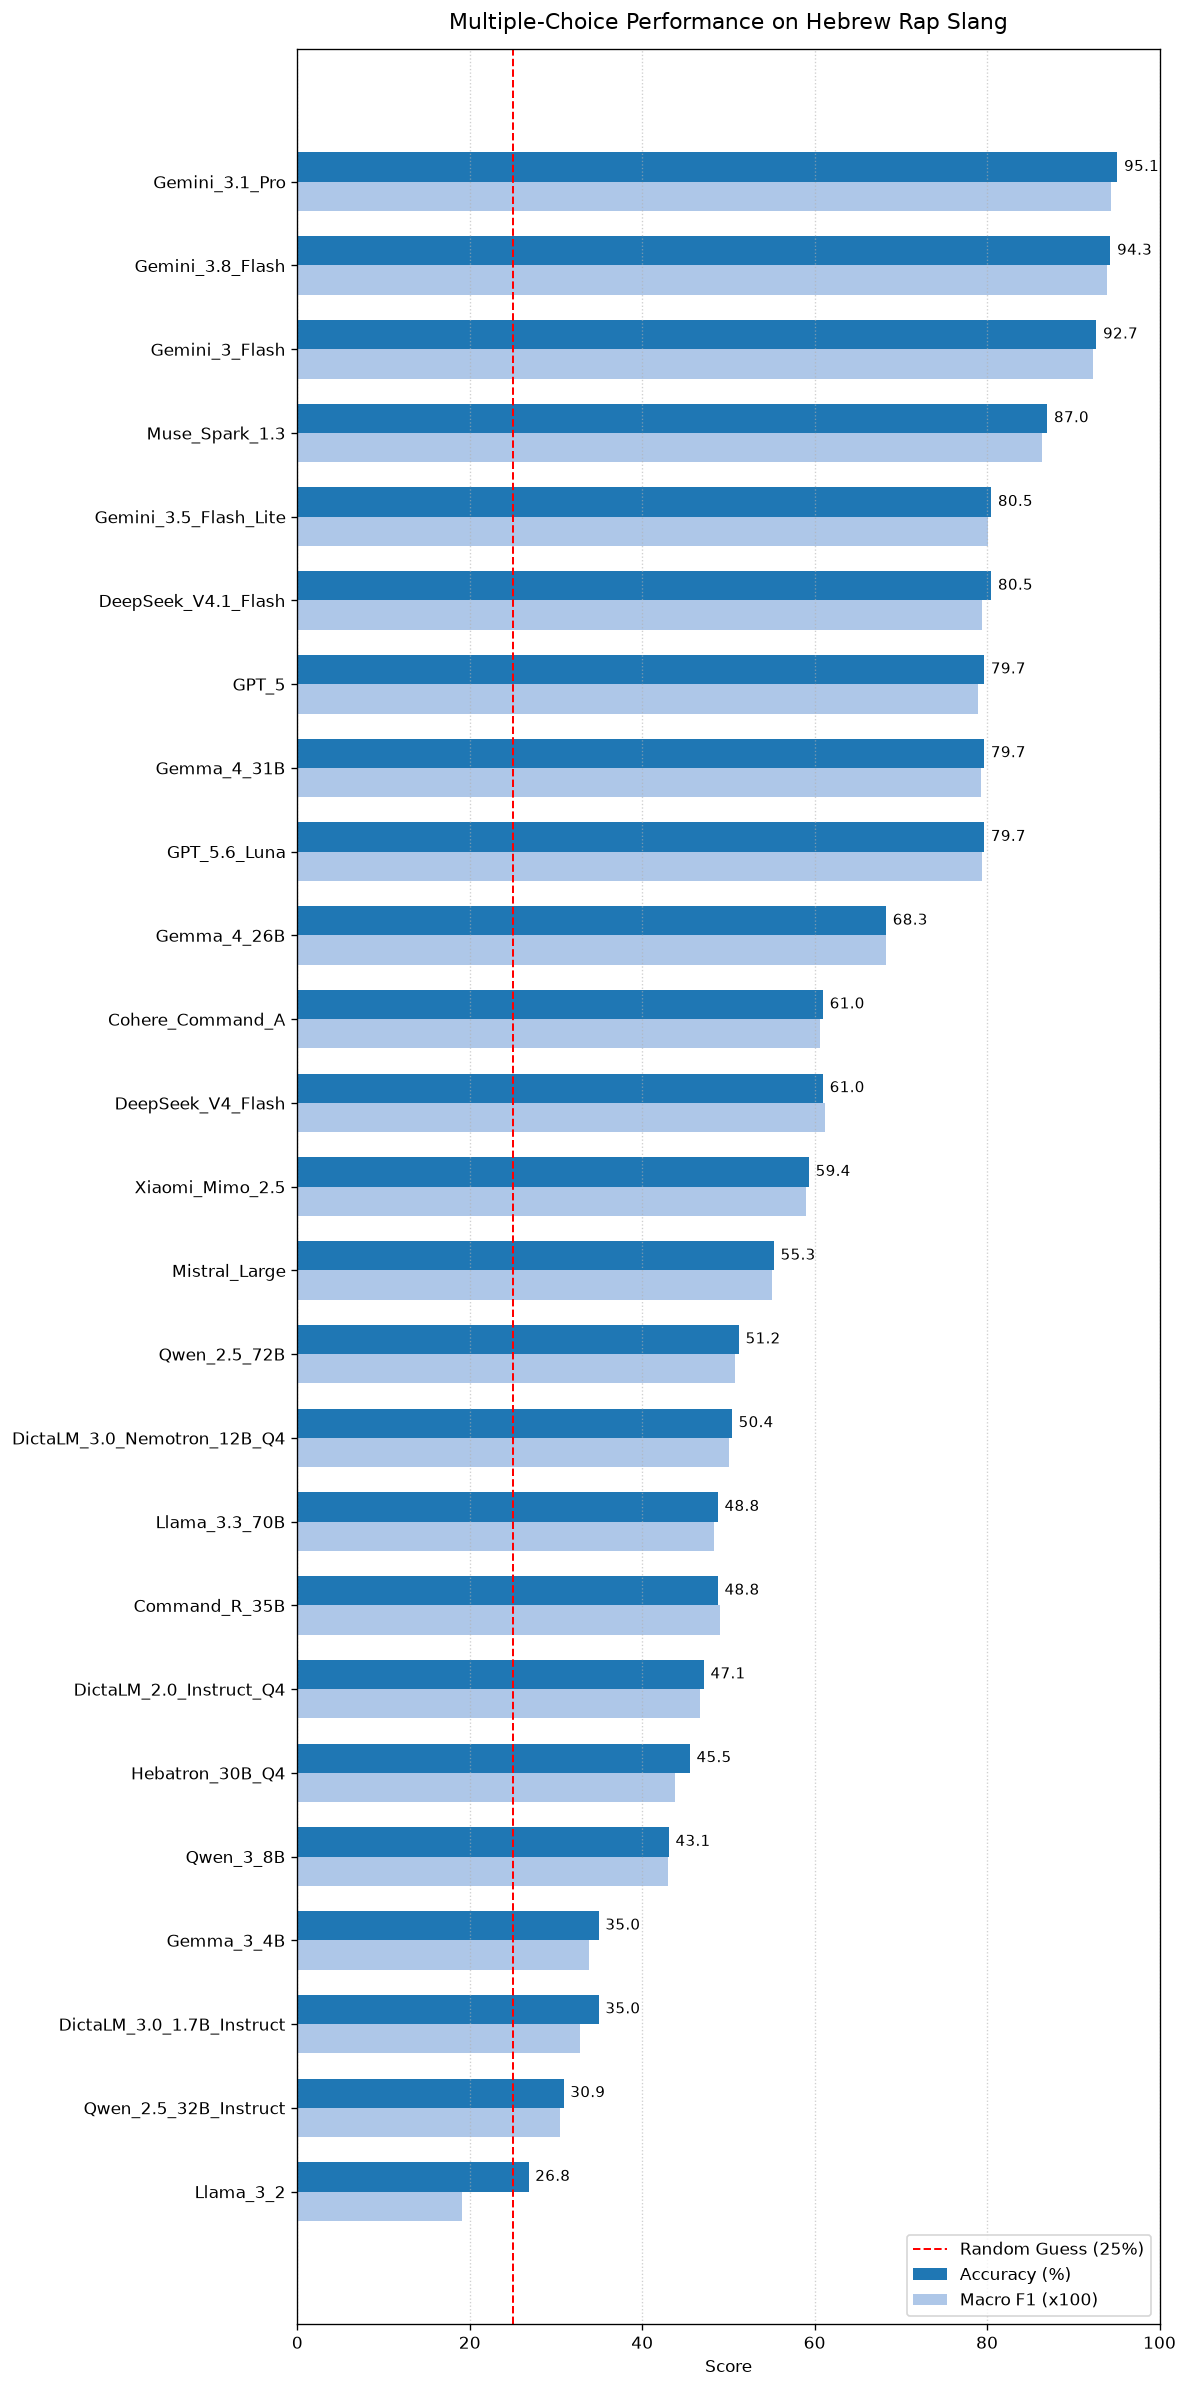

In [3]:
MC_DIR = Path("../data/results/multichoice")

HEBREW_TO_LATIN = {"א": "A", "ב": "B", "ג": "C", "ד": "D"}


def extract_option_letter(val, map_hebrew: bool = True) -> str:
    """Extracts a strict 'A', 'B', 'C', or 'D' option from model output."""
    if not val:
        return "INVALID"

    raw_str = ""
    if isinstance(val, dict):
        raw_str = str(val.get("selected_option", "")).strip()
    else:
        val_str = str(val).strip()
        try:
            parsed = json.loads(val_str)
            if isinstance(parsed, dict) and "selected_option" in parsed:
                raw_str = str(parsed["selected_option"]).strip()
        except Exception:
            pass

        if not raw_str:
            match = re.search(
                r'["\']?selected_option["\']?\s*:\s*["\']?([^"\'}\s,]+)',
                val_str,
                re.IGNORECASE,
            )
            if match:
                raw_str = match.group(1).strip()
            else:
                raw_str = val_str

    candidate = raw_str.upper()

    if map_hebrew and candidate in HEBREW_TO_LATIN:
        candidate = HEBREW_TO_LATIN[candidate]

    if candidate not in {"A", "B", "C", "D"}:
        letter_match = re.search(r"\b([A-D])\b", candidate)
        if letter_match:
            candidate = letter_match.group(1)
        elif map_hebrew:
            heb_match = re.search(r"([א-ד])", raw_str)
            if heb_match:
                candidate = HEBREW_TO_LATIN.get(heb_match.group(1), "INVALID")
        else:
            candidate = "INVALID"

    return candidate if candidate in {"A", "B", "C", "D"} else "INVALID"


mc_results = {}
detailed_predictions = {}

for model_name in sorted(READY_MODELS):
    p = MC_DIR / f"{model_name}.json"
    if not p.exists():
        continue

    with p.open("r", encoding="utf-8") as f:
        records = json.load(f)

    y_true = []
    y_pred = []

    for r in records:
        gt = str(r.get("correct_label", "")).strip().upper()
        raw_pred = (
            r.get("predicted_label")
            if r.get("predicted_label") is not None
            else r.get("raw_model_response")
        )
        pred = extract_option_letter(raw_pred, map_hebrew=True)

        y_true.append(gt)
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(
        y_true, y_pred, average="macro", labels=["A", "B", "C", "D"], zero_division=0
    )

    pred_series = pd.Series(y_pred)
    pred_counts = pred_series.value_counts().to_dict()
    valid_count = sum(pred_counts.get(k, 0) for k in ["A", "B", "C", "D"])
    invalid_count = len(y_true) - valid_count

    mc_results[model_name] = {
        "Accuracy (%)": round(acc * 100, 2),
        "Macro F1": round(macro_f1, 4),
        "Valid Formats": valid_count,
        "Total": len(y_true),
        "A": pred_counts.get("A", 0),
        "B": pred_counts.get("B", 0),
        "C": pred_counts.get("C", 0),
        "D": pred_counts.get("D", 0),
        "Invalid": invalid_count,
    }
    detailed_predictions[model_name] = pred_series

df_mc = pd.DataFrame.from_dict(mc_results, orient="index").sort_values(
    by="Accuracy (%)", ascending=False
)
display(df_mc)

df_mc["Macro F1 (Scaled)"] = df_mc["Macro F1"] * 100

plot_benchmark_leaderboard(
    df=df_mc,
    primary_col="Accuracy (%)",
    secondary_col="Macro F1 (Scaled)",
    title="Multiple-Choice Performance on Hebrew Rap Slang",
    primary_label="Accuracy (%)",
    secondary_label="Macro F1 (x100)",
    baseline=25.0,
    baseline_label="Random Guess (25%)",
)

## Part 2: Semantic Similarity Scoring

Initializing Gemini API Client for Embeddings...
Loaded all 123 embeddings from ground_truth.npz.

Processing Cohere_Command_A...
Loaded all 123 embeddings from Cohere_Command_A.npz.

Processing Command_R_35B...
Loaded all 123 embeddings from Command_R_35B.npz.

Processing DeepSeek_V4.1_Flash...
Loaded all 123 embeddings from DeepSeek_V4.1_Flash.npz.

Processing DeepSeek_V4_Flash...
Loaded all 123 embeddings from DeepSeek_V4_Flash.npz.

Processing DictaLM_2.0_Instruct_Q4...
Loaded all 123 embeddings from DictaLM_2.0_Instruct_Q4.npz.

Processing DictaLM_3.0_1.7B_Instruct...
Loaded all 123 embeddings from DictaLM_3.0_1.7B_Instruct.npz.

Processing DictaLM_3.0_Nemotron_12B_Q4...
Loaded all 123 embeddings from DictaLM_3.0_Nemotron_12B_Q4.npz.

Processing Gemini_3.1_Pro...
Loaded all 123 embeddings from Gemini_3.1_Pro.npz.

Processing Gemini_3.5_Flash_Lite...
Loaded all 123 embeddings from Gemini_3.5_Flash_Lite.npz.

Processing Gemini_3.8_Flash...
Loaded all 123 embeddings from Gemini_3.8_F

,Avg Cosine Score
GPT_5,78.82
Muse_Spark_1.3,78.07
GPT_5.6_Luna,77.41
Gemini_3.5_Flash_Lite,77.41
DeepSeek_V4.1_Flash,76.46
Gemini_3_Flash,76.28
Gemini_3.8_Flash,75.97
Gemini_3.1_Pro,75.88
Command_R_35B,75.54
Cohere_Command_A,75.42


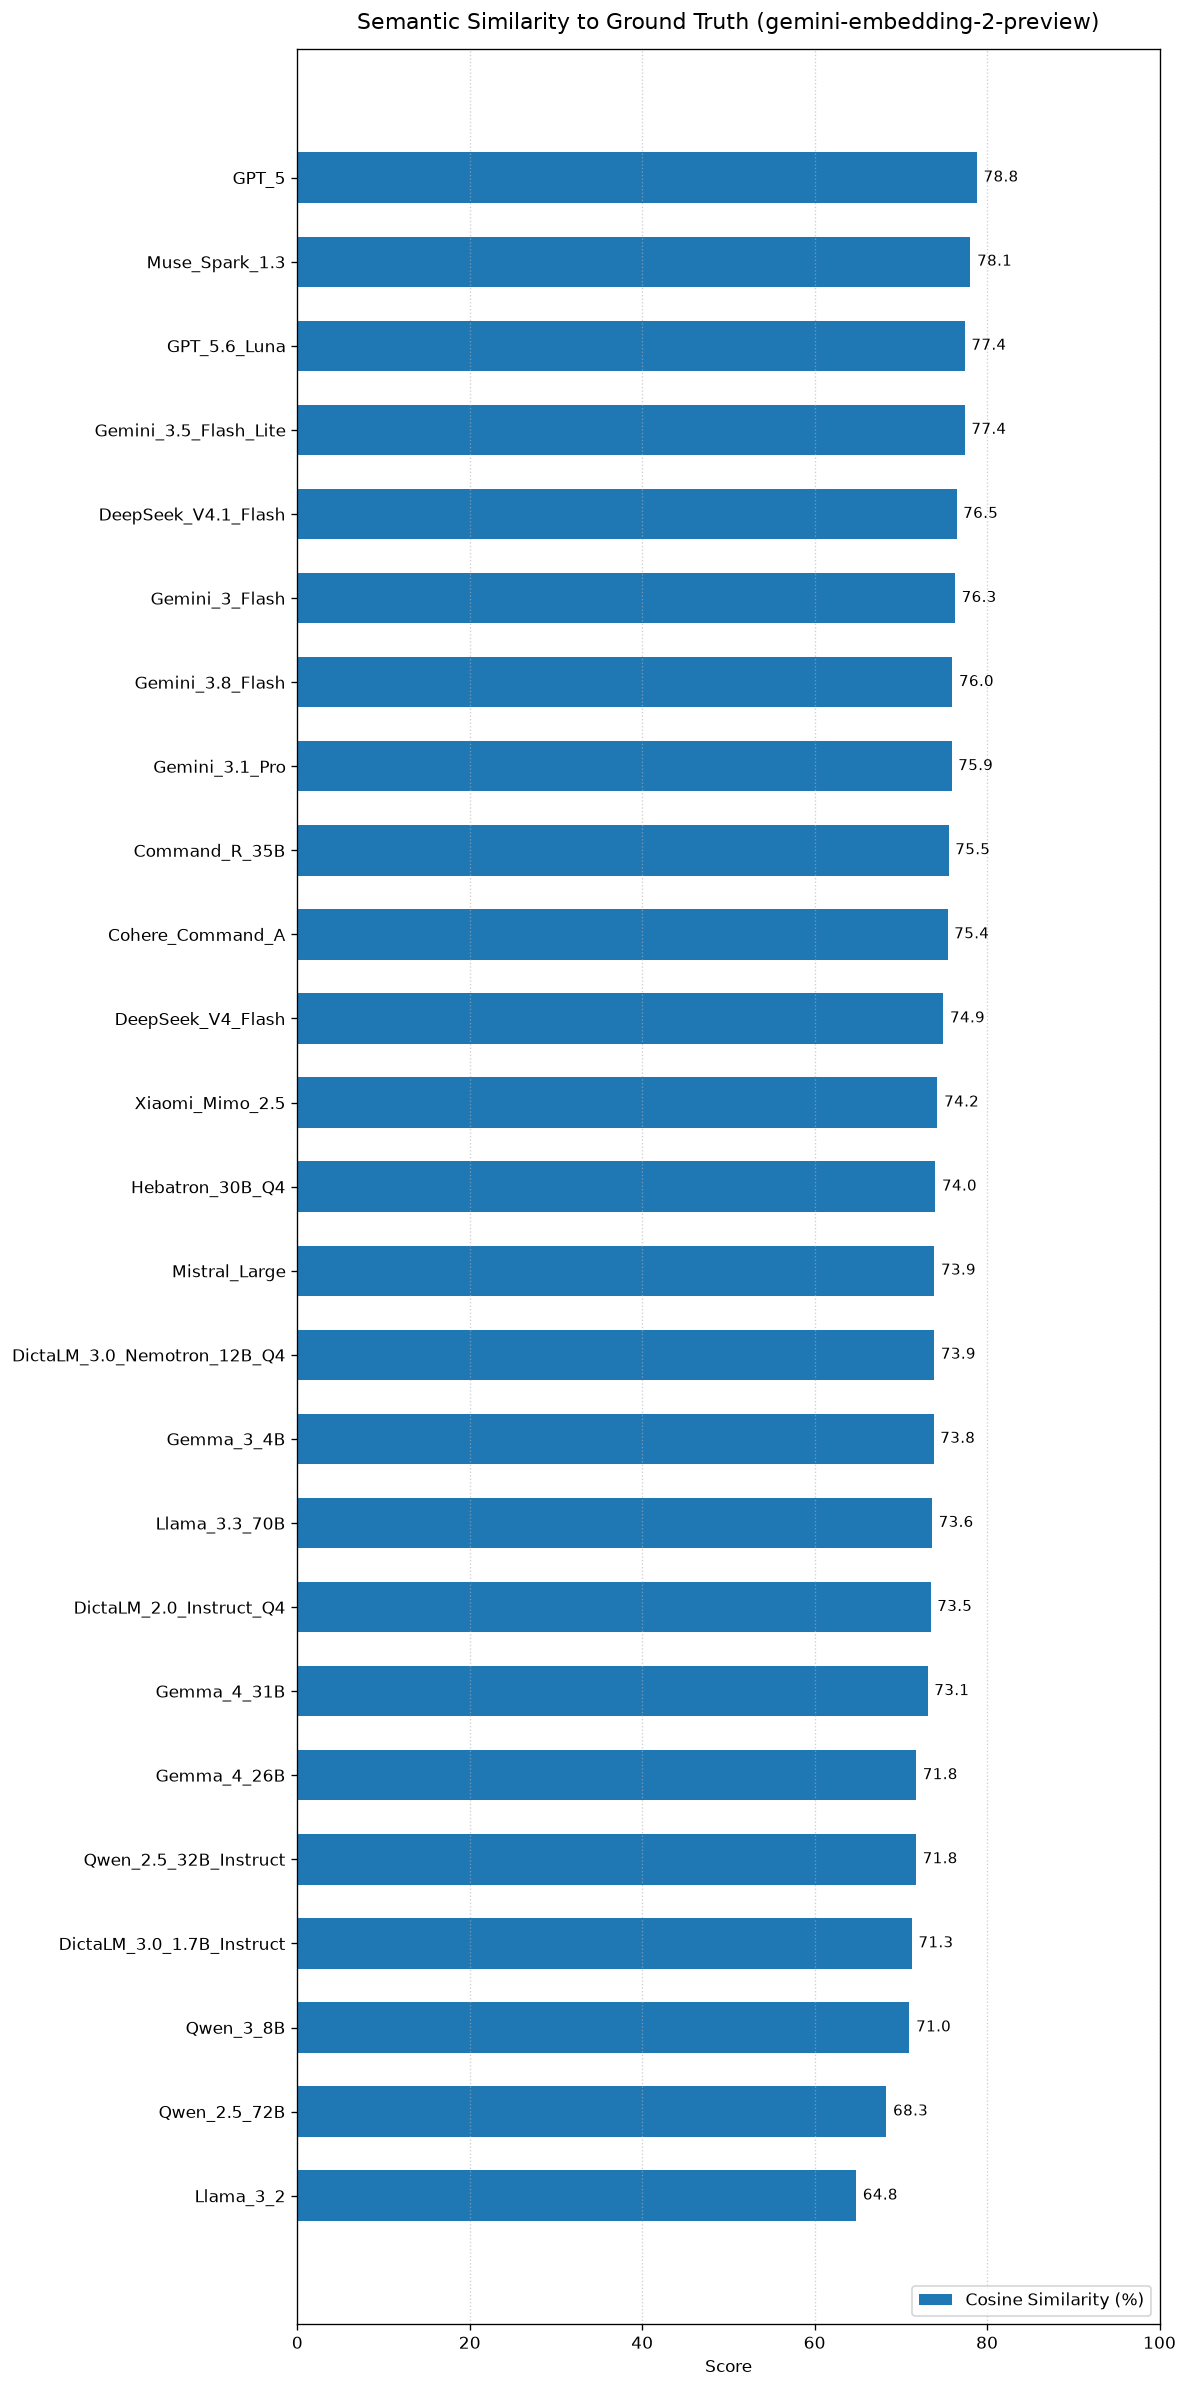

In [4]:
# 1. Paths & Directories
OPEN_DIR = Path("../data/results/open_ended")
EMBEDDINGS_DIR = Path("../data/evaluation/cached_embeddings")
GT_EMBEDDINGS_FILE = EMBEDDINGS_DIR / "ground_truth.npz"

EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

# 2. Client Initialization
print("Initializing Gemini API Client for Embeddings...")

client = OpenAI(
    api_key=GEMINI_KEY,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)


# 3. Embedding Caching & Batching Helpers
def load_cached_embeddings(npz_path: Path) -> dict[str, np.ndarray]:
    """Loads cached embeddings dictionary from an .npz file."""
    if not npz_path.exists():
        return {}
    data = np.load(npz_path)
    ids = [str(i) for i in data["ids"]]
    vectors = data["vectors"]
    return dict(zip(ids, vectors))


def save_cached_embeddings(npz_path: Path, cache: dict[str, np.ndarray]):
    """Flushes embedding vectors to disk as a compressed .npz archive."""
    ids = list(cache.keys())
    vectors = np.array(list(cache.values()), dtype=np.float32)
    np.savez_compressed(npz_path, ids=ids, vectors=vectors)


def get_or_compute_embeddings(
        items: list[tuple[str, str]],
        cache_path: Path,
        batch_size: int = 50,
) -> dict[str, np.ndarray]:
    """
    Fetches embeddings from cache or computes missing items via Gemini API.
    Flushes to disk incrementally after each batch to survive interruptions.
    """
    cache = load_cached_embeddings(cache_path)
    missing = [(item_id, text) for item_id, text in items if item_id not in cache]

    if missing:
        print(f"Computing {len(missing)} missing embeddings for {cache_path.stem}...")
        for i in tqdm(range(0, len(missing), batch_size), desc=f"Embedding {cache_path.stem}"):
            batch = missing[i: i + batch_size]
            batch_texts = [text.strip() if text.strip() else " " for _, text in batch]

            # OpenAI natively accepts a flat list of strings for batch embedding
            response = client.embeddings.create(
                model="gemini-embedding-2-preview",
                input=batch_texts
            )

            for (item_id, _), emb in zip(batch, response.data):
                cache[item_id] = np.array(emb.embedding, dtype=np.float32)

            # Persist on-the-run after every single batch
            save_cached_embeddings(cache_path, cache)
            time.sleep(1)
    else:
        print(f"Loaded all {len(items)} embeddings from {cache_path.name}.")

    return cache


def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    a, b = np.array(vec1), np.array(vec2)
    norm_a, norm_b = np.linalg.norm(a), np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))


# 4. Load Open-Ended Results
open_results = {}
for model_name in sorted(READY_MODELS):
    p = OPEN_DIR / f"{model_name}.json"
    if not p.exists():
        continue
    with p.open("r", encoding="utf-8") as f:
        open_results[model_name] = json.load(f)

# 5. Compute or Load Ground Truth Embeddings
first_model_records = next(iter(open_results.values()))
gt_tuples = [(r["id"], r.get("ground_truth", "")) for r in first_model_records]
gt_embeddings_map = get_or_compute_embeddings(gt_tuples, GT_EMBEDDINGS_FILE)

# 6. Compute Similarities, Update JSONs In-Place
similarity_scores = {}

for model_name, records in open_results.items():
    print(f"\nProcessing {model_name}...")
    model_tuples = [
        (r["id"], r.get("raw_model_response", "")[:4000]) for r in records
    ]
    model_cache_path = EMBEDDINGS_DIR / f"{model_name}.npz"
    model_embeddings_map = get_or_compute_embeddings(model_tuples, model_cache_path)

    scores = []
    for r in records:
        item_id = r["id"]
        gt_vec = gt_embeddings_map[item_id]
        resp_vec = model_embeddings_map[item_id]

        sim = cosine_similarity(gt_vec, resp_vec)
        scaled_sim = round(max(0.0, sim * 100.0), 2)
        scores.append(scaled_sim)

        # Annotate record in-place
        r["cosine_similarity"] = scaled_sim

    # Save enriched record list back to disk
    result_path = OPEN_DIR / f"{model_name}.json"
    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    similarity_scores[model_name] = {
        "Avg Cosine Score": round(float(np.mean(scores)), 2)
    }

# 7. Display Leaderboard & Render Visualization
df_sim = pd.DataFrame.from_dict(similarity_scores, orient="index")
df_sim = df_sim.sort_values(by="Avg Cosine Score", ascending=False)

print("\n" + "=" * 50)
print("AVERAGE SEMANTIC SIMILARITY SCORE (0-100)")
print("=" * 50)
display(df_sim)

plot_benchmark_leaderboard(
    df=df_sim,
    primary_col="Avg Cosine Score",
    title="Semantic Similarity to Ground Truth (gemini-embedding-2-preview)",
    primary_label="Cosine Similarity (%)",
)

## Part 3: LLM-as-a-Judge Scoring

In [ ]:
# 1. Paths & Initialization
OPEN_DIR = Path("../data/results/open_ended")
JUDGE_CACHE_DIR = Path("../data/evaluation/llm_as_a_judge_caching")

JUDGE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Initializing Gemini API Client for LLM-as-a-Judge...")

client = OpenAI(
    api_key=GEMINI_KEY,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

# 2. Judge Prompt Template
JUDGE_PROMPT_TEMPLATE = """
You are an expert linguistic judge evaluating an AI model's understanding of Israeli hip-hop slang.

You will be given a slang fragment, the ground truth explanation (what it actually means), and the AI model's predicted explanation.
Your task is to grade the AI model's explanation strictly on factual accuracy and semantic equivalence to the ground truth.

Fragment:
{fragment}

Ground Truth Explanation:
{ground_truth}

AI Model Explanation:
{model_response}

Rubric:
100: The model's explanation perfectly captures the meaning of the slang in this context.
75: The explanation is mostly correct but misses a minor nuance.
50: The explanation is partially correct but gets significant parts wrong or is too vague.
25: The explanation is mostly incorrect but has a tiny grain of truth.
0: The explanation is completely wrong, hallucinates, or is irrelevant.

Output your evaluation strictly as a JSON object with two keys:
- "score": an integer representing the grade (0, 25, 50, 75, or 100).
- "reasoning": a one-sentence justification for the score.
"""


def evaluate_single_response(fragment: str, ground_truth: str, model_response: str) -> dict:
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        fragment=fragment,
        ground_truth=ground_truth,
        model_response=str(model_response)[:4000]
    )

    messages: list[ChatCompletionMessageParam] = [{"role": "user", "content": prompt}]
    response = client.chat.completions.create(
        model="gemini-3.8-flash",
        messages=messages,
        temperature=0.0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content or "{}"
    result = json.loads(content)
    score = int(result.get("score", 0))
    reasoning = str(result.get("reasoning", "Failed to parse reasoning."))

    return {"score": score, "reasoning": reasoning}


def load_judge_cache(path: Path) -> dict:
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_judge_cache(path: Path, cache: dict):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)


llm_judge_scores = {}

print("\nRunning LLM-as-a-Judge Evaluation...")

# 4. Evaluate and Update In-Place
for model_name, records in open_results.items():
    print(f"\nEvaluating {model_name}...")

    # Model-specific paths
    result_path = OPEN_DIR / f"{model_name}.json"
    cache_path = JUDGE_CACHE_DIR / f"{model_name}.json"

    model_cache = load_judge_cache(cache_path)
    scores = []

    for r in tqdm(records, desc=f"Judging {model_name}"):
        item_id = r.get("id")

        # Check cache first using the stable item_id
        if item_id in model_cache:
            evaluation = model_cache[item_id]
        else:
            fragment = r.get("fragment", "")
            ground_truth = r.get("ground_truth", "")
            model_resp = r.get("raw_model_response", "")

            try:
                evaluation = evaluate_single_response(fragment, ground_truth, model_resp)

                # 1. Update cache map
                model_cache[item_id] = evaluation
                # 2. Flush to disk immediately
                save_judge_cache(cache_path, model_cache)

                time.sleep(2)  # Respect rate limits for sequential calls

            except Exception as e:
                print(f"\n[!] Error or Quota Exhaustion on item {item_id}: {e}")
                # Crash immediately so we don't proceed with corrupted data
                raise e

        # Track for final average
        score = evaluation["score"]
        scores.append(score)

        # Annotate the actual open-ended record in-place
        r["llm_judge_score"] = score
        r["llm_judge_reasoning"] = evaluation["reasoning"]

    # Once the model is fully graded, save the enriched records back to OPEN_DIR
    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    llm_judge_scores[model_name] = {
        "Avg Judge Score": round(float(np.mean(scores)), 2)
    }

# 5. Display Leaderboard & Render Visualization
df_judge = pd.DataFrame.from_dict(llm_judge_scores, orient="index")
df_judge = df_judge.sort_values(by="Avg Judge Score", ascending=False)

print("\n" + "=" * 50)
print("LLM-AS-A-JUDGE SCORES (0-100)")
print("=" * 50)
display(df_judge)

plot_benchmark_leaderboard(
    df=df_judge,
    primary_col="Avg Judge Score",
    title="LLM-as-a-Judge Accuracy (gemini-3.8-flash)",
    primary_label="Factual Accuracy Score"
)

Initializing Gemini API Client for LLM-as-a-Judge...

Running LLM-as-a-Judge Evaluation...

Evaluating Cohere_Command_A...


Judging Cohere_Command_A:   0%|          | 0/123 [00:00<?, ?it/s]


Evaluating Command_R_35B...


Judging Command_R_35B:   0%|          | 0/123 [00:00<?, ?it/s]


Evaluating DeepSeek_V4.1_Flash...


...

Judging Gemini_3_Flash:   0%|          | 0/123 [00:00<?, ?it/s]


Evaluating Gemma_3_4B...


Judging Gemma_3_4B:   0%|          | 0/123 [00:00<?, ?it/s]


Evaluating Gemma_4_26B...


Judging Gemma_4_26B:   0%|          | 0/123 [00:00<?, ?it/s]

## Part 4: Aggregated Leaderboard & Visualization

In [ ]:
# 1. Merge the three dataframes using their indexes (model names)
df_final = df_mc[['Accuracy (%)']].copy()
df_final = df_final.rename(columns={'Accuracy (%)': 'MC Accuracy'})

# Join the scores from the other tests
df_final['Cosine Similarity'] = df_sim['Avg Cosine Score']
df_final['Judge Score'] = df_judge['Avg Judge Score']

# 2. Calculate the Weighted Composite Score (50/30/20)
df_final['Final Grade'] = (
        (df_final['Judge Score'] * 0.50) +
        (df_final['MC Accuracy'] * 0.30) +
        (df_final['Cosine Similarity'] * 0.20)
).round(2)

# Sort from best to worst
df_final = df_final.sort_values(by='Final Grade', ascending=False)

print("\n" + "=" * 60)
print("FINAL COMPOSITE LEADERBOARD (50% Judge / 30% MC / 20% Cos)")
print("=" * 60)
display(df_final)

# 3. Render the grand finale visualization
plot_benchmark_leaderboard(
    df=df_final,
    primary_col="Final Grade",
    title="Final Hebrew Rap Slang Comprehension Grade",
    primary_label="Composite Score (0-100)",
    xlim=(0, 100)
)